# **Analyzing the Housing Market in Ames, Iowa to Predict House Prices**

## **Introduction :**

Over the past few years, housing has changed a lot. Rising incomes, higher living costs, and homeowners wanting better upgrades have reshaped how houses are built and designed. Even rural areas have seen sharp price increases.

Usually when somebody considering to buy house consider the neighborhood, type of house, attributes of the house, type of sale, and time are factored into the price. We will try to understand these factors and how they influence the housing market in Ames, Iowa. We will also try to understand how they may have affected the price of houses over time to see the change that was explained above.

Our primary feature of interest is `SalePrice`, representing the final selling price of each house. In this notebook, we conduct multiple analysis through graphs and statistical tests to identify which additional features provide meaningful insights for addressing our analysis questions. 

### **GOAL**

The goal is to explore questions mentioned below:

1. Which factors most strongly influence house prices in Ames, Iowa?

. How does location within a city affect the sale price of homes?

. How do a home's age and whether it has been remodeled affect its price?

. What is the housing market like in Ames, Iowa? Specifically, what kind of houses are in Ames, how do they vary by neighborhood, and how have amenities of houses changed over time?

. What impact does geographic location have on property values in Ames, Iowa?

. How does the way a house is sold affect its sale price? Specifically, how do the sale type and sale condition relate to sale price and reveal homeowner patterns?

. How do a house's quality and condition affect house price, and how does the average sale price change over time with the economy?


#### **Ames Housing Data Description**

The data was collected by De Cock where 81 dimensions were recorded for 1460 properties in Ames IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier).

__2. Sale Information__
- **SalePrice:** Target variable — final selling price.
- **SaleType:** Type of sale (e.g., Warranty Deed).
- **SaleCondition:** Condition of sale (Normal, Abnormal, Partial).

__3. Lot & Land__
- **MSSubClass:** Dwelling type (e.g., 1-story, 2-story).
- **MSZoning:** Zoning classification.
- **LotFrontage:** Street frontage length.
- **LotArea:** Lot size (sq ft).
- **Street:** Road access type.
- **Alley:** Alley access type.
- **LotShape:** Lot shape (Regular, Irregular).
- **LandContour:** Flatness of property.
- **Utilities:** Available utilities.
- **LotConfig:** Lot configuration (Corner, Inside).
- **LandSlope:** Slope of property.
- **Neighborhood:** Physical location within Ames.
- **Condition1/Condition2:** Proximity to roads, railways, etc.

__4. Building & Construction__

- **BldgType:** Building type (Single-family, Duplex).
- **HouseStyle:** House style (1-story, 2-story, split-level).
- **OverallQual:** Overall material/finish quality (1–10).
- **OverallCond:** Overall condition (1–10).
- **YearBuilt:** Year built.
- **YearRemodAdd:** Remodel year.
- **RoofStyle:** Roof type.
- **RoofMatl:** Roof material.
- **Exterior1st/Exterior2nd:** Exterior covering materials.
- **MasVnrType:** Masonry veneer type.
- **MasVnrArea:** Masonry veneer area (sq ft).
- **ExterQual:** Exterior quality.
- **ExterCond:** Exterior condition.

__5. Interior Features__

- **Foundation:** Foundation type.
- **BsmtQual:** Basement quality.
- **BsmtCond:** Basement condition.
- **BsmtExposure:** Basement exposure (walkout, garden).
- **BsmtFinType1/BsmtFinType2:** Basement finish types.
- **BsmtFinSF1/BsmtFinSF2:** Finished basement area (sq ft).
- **BsmtUnfSF:** Unfinished basement area.
- **TotalBsmtSF:** Total basement area.
- **Heating:** Heating type.
- **HeatingQC:** Heating quality.
- **CentralAir:** Central air (Y/N).
- **Electrical:** Electrical system.
- **1stFlrSF:** First floor area.
- **2ndFlrSF:** Second floor area.
- **LowQualFinSF:** Low-quality finished area.
- **GrLivArea:** Above-ground living area.
- **BsmtFullBath/BsmtHalfBath:** Basement bathrooms.
- **FullBath/HalfBath:** Bathrooms above ground.
- **BedroomAbvGr:** Bedrooms above ground.
- **KitchenAbvGr:** Kitchens above ground.
- **KitchenQual:** Kitchen quality.
- **TotRmsAbvGrd:** Total rooms above ground.
- **Functional:** Home functionality rating.
- **Fireplaces:** Number of fireplaces.
- **FireplaceQu:** Fireplace quality.

__6. Garage__
- **GarageType:** Garage location.
- **GarageYrBlt:** Year garage built.
- **GarageFinish:** Garage finish.
- **GarageCars:** Garage capacity (cars).
- **GarageArea:** Garage area (sq ft).
- **GarageQual:** Garage quality.
- **GarageCond:** Garage condition.

**7.Outdoor & Misc**

- **PavedDrive:** Paved driveway (Y/N).
- **WoodDeckSF:** Wood deck area (sq ft).
- **OpenPorchSF:** Open porch area.
- **EnclosedPorch:** Enclosed porch area.
- **3SsnPorch:** Three-season porch area.
- **ScreenPorch:** Screen porch area.
- **PoolArea:** Pool area (sq ft).
- **PoolQC:** Pool quality.
- **Fence:** Fence quality.
- **MiscFeature:** Miscellaneous features (shed, tennis court).
- **MiscVal:** Value of miscellaneous features.

__8. Living Space Totals__
- **MoSold:** Month sold.
- **YrSold:** Year sold.

**This dataset represents the sale of  residential properties in Ames, Iowa, where every single record represents a sale of individual house.
There are identification, location, land lot information, house characteristics, exterior, interior, garge, sales information and other features describing each house. The data spans from 2006 to 2010.**

### __Import Libraries__


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sidetable
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm

### __Display Setting__

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
# set the decimal places to 2
pd.set_option("display.float_format", "{:.2f}".format)

### **Basic Understanding & Data Ingestion**

In [3]:
path = Path.cwd().parent
data_path = path.joinpath("data", "raw")
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [4]:
# Read train and test
df_train = pd.read_csv(files[2])
df_test = pd.read_csv(files[1])
print("Training Dataset:")
display(df_train.head(1))
print("\n")
print("Testing Dataset:")
display(df_test.head(1))


Training Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500




Testing Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal


In [5]:
# Basic info of datasets
print(f"Training Dataset Shape : {df_train.shape}")
print(f"Testing Dataset Shape : {df_test.shape}")


Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


In [6]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

df_train.columns = df_train.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")#.str.lower()
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

### **Columns Formatting and Consistency**

In [7]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df


,Dtype,nunique,unique
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotFrontage,float64,110,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, nan..."
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
Street,object,2,"[Pave, Grvl]"
Alley,object,2,"[nan, Grvl, Pave]"
LotShape,object,4,"[Reg, IR1, IR2, IR3]"
LandContour,object,4,"[Lvl, Bnk, Low, HLS]"
Utilities,object,2,"[AllPub, NoSeWa]"


In [8]:
miss_train_df = df_train.stb.missing().query("percent > 0")
miss_train_df.head()

,missing,total,percent
PoolQC,1453,1460,99.52
MiscFeature,1406,1460,96.30
Alley,1369,1460,93.77
Fence,1179,1460,80.75
MasVnrType,872,1460,59.73


In [9]:
miss_test_df = df_test.stb.missing().query("percent > 0")
miss_test_df.head()

,missing,total,percent
PoolQC,1456,1459,99.79
MiscFeature,1408,1459,96.50
Alley,1352,1459,92.67
Fence,1169,1459,80.12
MasVnrType,894,1459,61.27


In [10]:
set(miss_train_df.index) == set(miss_test_df.index)

False

In [11]:
def highlight_zero_negative(val):
    if val < 0:
        return 'background-color: red; color: white;'  # Negative values styled in red
    elif val == 0:
        return 'background-color: yellow; color: black;'  # Zero values styled in yellow
    else:
        return ''  # No styling for positive values

def highlight_repeats(series):
    is_repeat = series.duplicated(keep=False)  # Identify repeated values
    return ['background-color: green; color: white' if repeat else '' for repeat in is_repeat]


In [12]:
# Formatting and data description for numerical features
df_descb = df_train.describe(include=['number'])
display(df_descb.style.applymap(highlight_zero_negative))


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [13]:
df_descb.style.apply(highlight_repeats)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


- Will explore occurrence more than 2 in columns if data type of columns is not ordinal it's need to explore else fine. 

### **Exploratory Data Analysis with Charts**

Let's explore the questions that were outlined in the goal section:



`Question 1.` Which factors most strongly influence house prices in Ames, Iowa?



To better understand how each variable influences sale prices, we examine the correlation heatmap of all quantitative features.

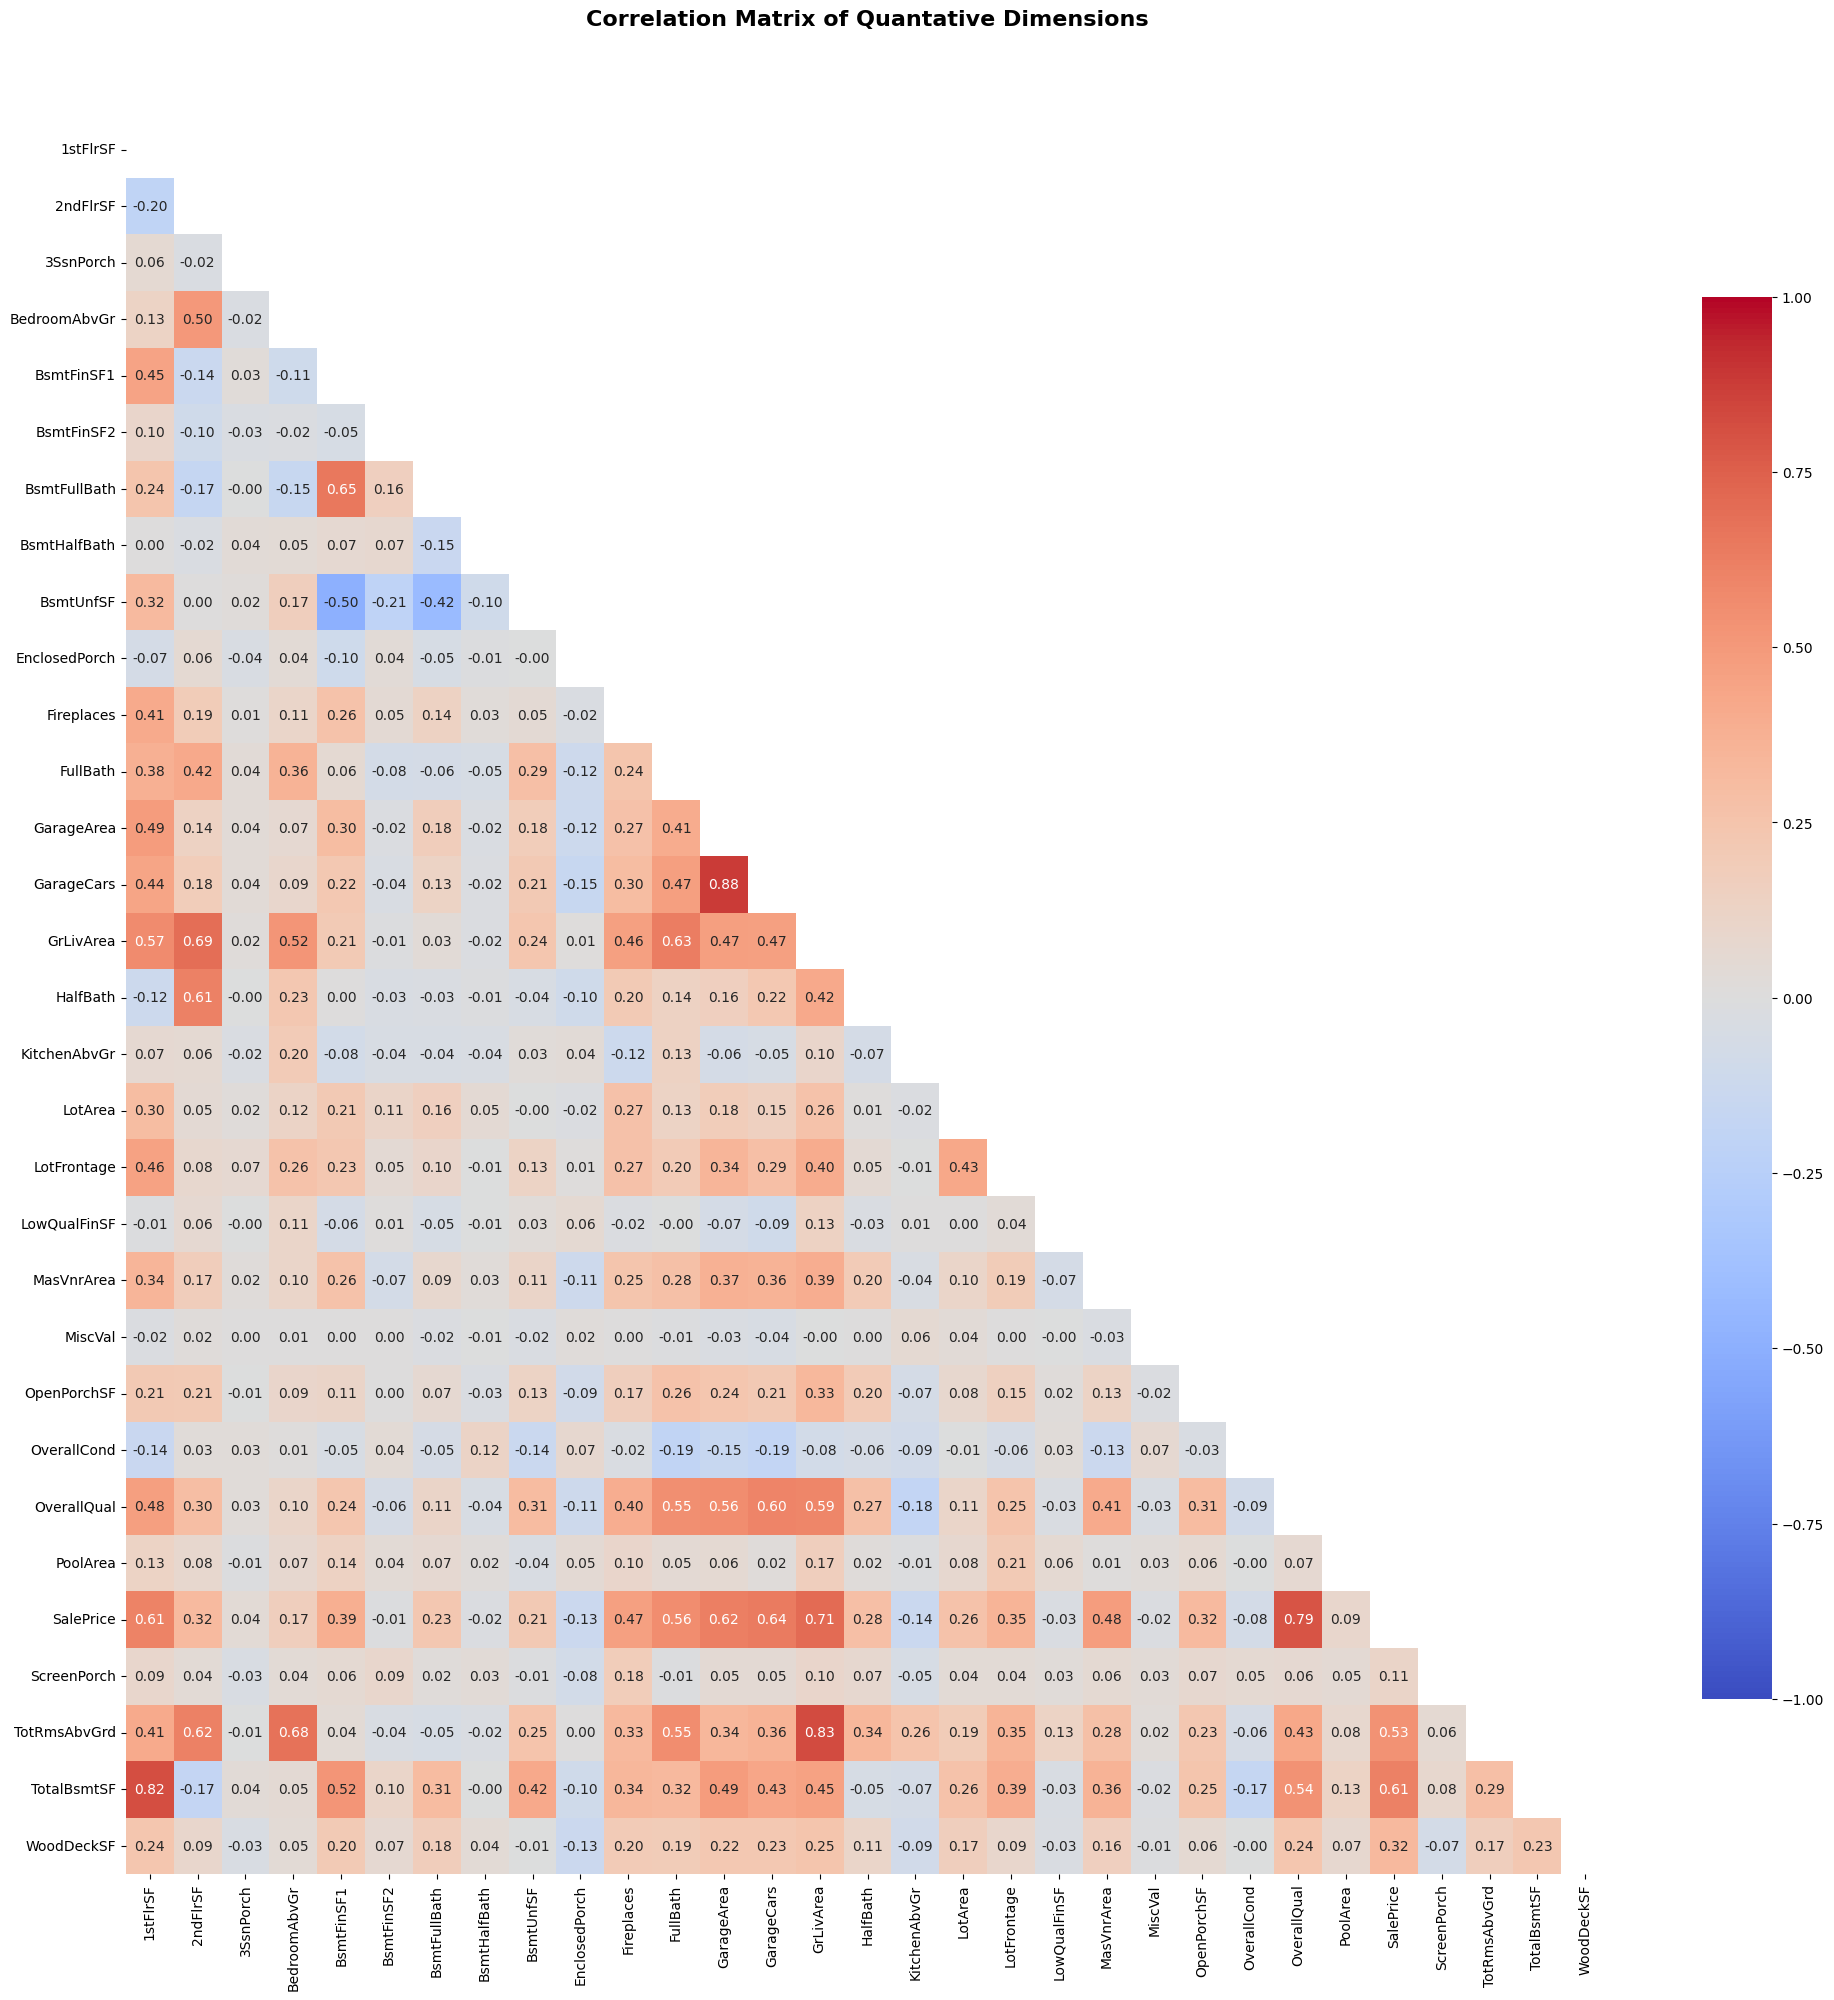

In [103]:
# Compute correlaton matrix
# select only numeric features other than time related dimensions
num_cols = df_train.select_dtypes("number").columns.difference(['Id', 'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold','MSSubClass', 'GarageYrBlt'])
num_df = df_train[num_cols]

# Compute Correlation Matrix
corr_df = num_df.corr()

# Visualization
fig, ax = plt.subplots(figsize=(20, 20))
mask = np.triu(np.ones_like(corr_df, dtype='bool'))
sns.heatmap(
    corr_df, mask=mask, 
    cmap='coolwarm', cbar=True,
    cbar_kws={'shrink' : .8},
    vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax
)

ax.set_title("Correlation Matrix of Quantative Dimensions", fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

`Question 2`. How does location within a city affect the sale price of homes?

`Question `. What is the housing market like in Ames, Iowa? Specifically, what kind of houses are in Ames, how do they vary by neighborhood, and how have amenities of houses changed over time?

To answer above question, we want to explore the types of houses being sold in Ames, Iowa to better understand the local housing market. This means looking at features like house styles, neighborhoods, and amenities such as garages, pools and porches, and how these have changed over time. By studying these features, we can gain context for the housing trends in Ames and see why certain pricing patterns occur.

To beign, we'll look at how houses are distributed/spread out to see if different styles form clear groups using multi-dimensional scaling.

In [14]:
df_train['HouseStyle'].value_counts()

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

In [15]:
# Select relevant columns
cols = ["LotArea", "MasVnrArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
        "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
        "3SsnPorch", "ScreenPorch", "PoolArea"]
new_df = df_train.copy()
house_df = new_df[cols].copy()

# Fill missing values with 0
house_new_df = house_df.fillna(0)

# Scale features by standard deviation
scaler = StandardScaler(with_mean=False)
house_scaled_df = scaler.fit_transform(house_new_df)

# Compute distance matrix and apply MDS
mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
house_mds = mds.fit_transform(house_scaled_df)

# Add MDS results back to dataframe
new_df['MDS1'] = house_mds[:, 0]
new_df['MDS2'] = house_mds[:, 1]

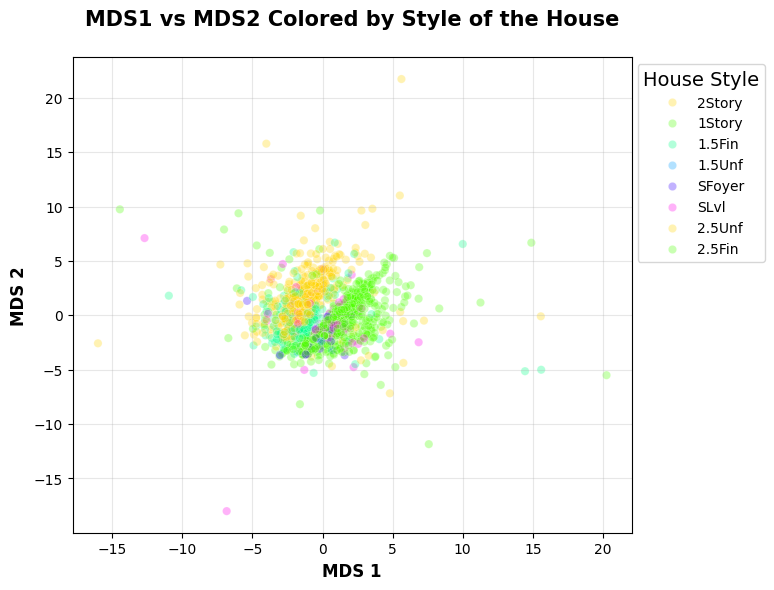

In [16]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=new_df, x='MDS1', y='MDS2', hue='HouseStyle', palette=sns.color_palette("hsv"), alpha=0.3, ax=ax)
ax.set_title("MDS1 vs MDS2 Colored by Style of the House", fontsize=15, fontweight='bold', y=1.05)
ax.set_xlabel("MDS 1", fontsize=12, fontweight='bold')
ax.set_ylabel("MDS 2", fontsize=12, fontweight='bold')
ax.legend(title="House Style", title_fontsize=14, bbox_to_anchor=(1.25, 1), loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows 3 main clusters : 
- A __green cluster__ for houses similar to typical 1-story homes.
- A __yellow cluster__ for houses similar to typical 2-story homes.
- A __sea green cluster__ for houses similar to 1.5 story home with partial second level finished.

This not only highlights similarities between houses but also shows how common each style is. 

Visually, 1‑story, 2‑story, and 1.5‑story homes are much more frequent than other styles.

When we look at the houses in Ames using their features (like size, garage, porches, etc.), the data naturally splits into mainly __three big groups__. Each group matches a common house style:
- 1 story homes
- 2 story homes
- 1.5 story homes (where the second floor is partly built)

This happens because the features of these houses are different enough that the math separates them into clusters. And it makes sense: usually, **1‑story homes cost less than 2‑story homes**, so the differences in features also show up in prices.

**In short: the clusters prove that house style really matters — both in how homes are built and how much they sell for.**

Another question is how different housing styles are spread across Iowa’s neighborhoods. Our dataset covers about 25 neighborhoods, so we can ask: do certain areas have more of one style than others, and are some neighborhoods more affluent? To explore this, we use a stacked bar chart, focusing only on 1‑story, 2‑story, and 1.5‑story homes for clarity.

Top 3 Neighborhood Sales :
 Neighborhood
NAmes      196
CollgCr    144
OldTown     98
Name: Count, dtype: int64 



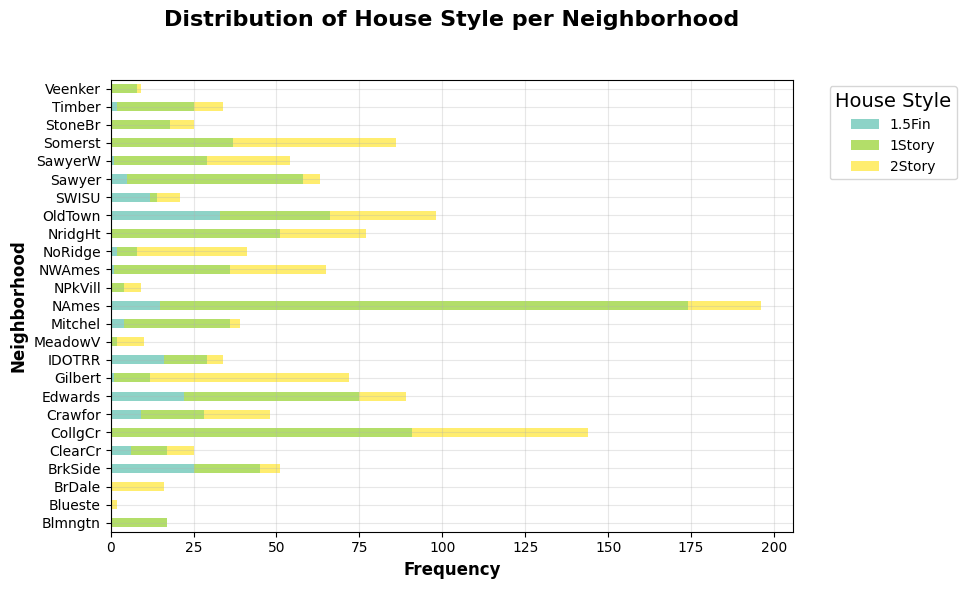

In [17]:
# Filtered only the selected house styles
filtered_df = new_df[new_df['HouseStyle'].isin(["1Story", "2Story", "1.5Fin"])]

# Count house styles per neighborhood
style_counts = filtered_df.groupby(["Neighborhood", "HouseStyle"]).size().unstack(fill_value=0)
top_3_sales = style_counts.stack().reset_index(name='Count')
top_3_sales = top_3_sales.groupby(['Neighborhood'])['Count'].sum().nlargest(3)
print(f"Top 3 Neighborhood Sales :\n {top_3_sales}", "\n")

# Plot bar chart and custom palette
fig, ax = plt.subplots(figsize=(10, 6))
style_counts.plot(kind='barh', stacked=True, ax=ax, colormap="Set3")
# Titles and labels
ax.set_title("Distribution of House Style per Neighborhood", fontsize=16, fontweight='bold', y=1.10)
ax.set_xlabel("Frequency", fontsize=12, fontweight='bold')
ax.set_ylabel("Neighborhood", fontsize=12, fontweight='bold')
ax.legend(title='House Style', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.25, 1), fancybox=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From this chart many things become apparent(clearly visible).The chart shows that house sales weren't evenly spread across neighborhoods. A few areas — like North Ames, College Creek, and Old Town — had far more houses than the average neighborhood(17.666 average count of neighborhood by house style).

In [18]:
hs_2_df = style_counts.stack().unstack()#.reset_index(name='Count')
hs_2_df.nlargest(3, columns='2Story')

HouseStyle,1.5Fin,1Story,2Story
Neighborhood,,,
Gilbert,1,11,60
CollgCr,0,91,53
Somerst,0,37,49


Looking at housing styles by neighborhood shows that some areas have more space for 2‑story homes(or large homes), which reduces the number of 1‑story and 1.5‑story houses. Neighborhoods like Gilbert, College Creek, and Somerset stand out with a higher share of 2‑story homes, suggesting they are more affluent(rich). This matches outside information too — for example, bing.com  ranks Gilbert as the best place in the county to raise a family, and all three are considered safe and welcoming parts of Ames.

__Key Finding: more 2‑story homes usually signal wealthier neighborhoods, and in Ames, Gilbert, College Creek, and Somerset fit that pattern.__


In [19]:
filtered_df["HouseStyle"].value_counts(normalize=True)

HouseStyle
1Story   0.55
2Story   0.34
1.5Fin   0.12
Name: proportion, dtype: float64

In these neighborhoods, fewer than half the homes are 1.5‑story. Since 1.5‑story houses aren't linked to low‑income areas, the main point is that neighborhoods with more 2‑story homes are wealthier, even if they have fewer houses overall.

**Key Finding : more 2‑story homes signal wealthier neighborhoods, while 1.5‑story homes don’t necessarily indicate lower income areas.**

To understand the housing market better, its important to look at the amenities homes offer. Features like bigger garages, porch or finished basements are often seen as luxuries, and we expect them to become more common as houses modernize. The key questions are: how have these amenities grown over time, which ones matter most, and what trends does each show? We demonstrate this with a time‑series plot.

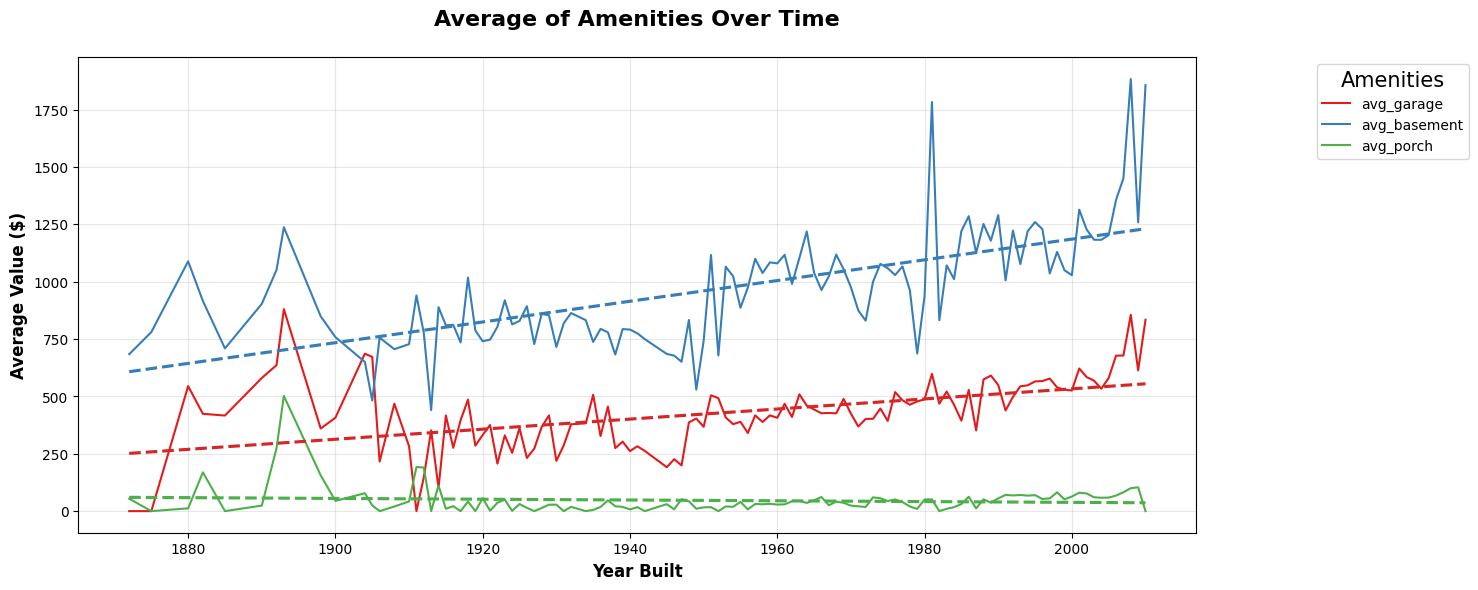

In [20]:
# Aggregrate the data on garage, porch and basement by year
amenities = (
    new_df.groupby(['YearBuilt'])
    .agg(
        avg_garage = ('GarageArea', 'mean'),
        avg_basement = ('TotalBsmtSF', 'mean'),
        avg_porch = ('OpenPorchSF', 'mean')
    )
    .reset_index()
)
# Reshape to long format
df_amenities = amenities.melt(
    id_vars='YearBuilt',
    value_vars = ['avg_garage', 'avg_basement', 'avg_porch'],
    var_name = 'Amenities',
    value_name = 'Average_value'
)
df_amenities.head()

# Visualization
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=df_amenities, x='YearBuilt', y='Average_value', hue='Amenities', palette="Set1", ax=ax)

# Custome colors for amenities
colors = {
    'avg_garge':'#e41a1c',
    'avg_basement':'#377eb8',
    'avg_porch':'#4daf4a'
}
# Add linear trend for each amenity indiviually
for amenity in df_amenities['Amenities'].unique():
    df_sub = df_amenities[df_amenities['Amenities']==amenity]
    sns.regplot(data=df_sub, x='YearBuilt', y='Average_value', scatter=False, ci=None, line_kws={'ls':'--'},color=colors.get(amenity))

ax.set_title("Average of Amenities Over Time", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Value ($)", fontsize=12, fontweight='bold')
ax.legend(title='Amenities', title_fontsize=15, loc='upper right', bbox_to_anchor=(1.25, 1), fancybox=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Above is time series charts, which plots YearBuilt on x-axis and the average value (in dollars) on y-axis. We separated each amenity by its own colored to track its change/movement over time. This plot shows how average garage, basement, and porch sizes have changed over time. Garages and basements have grown larger, while porches have become smaller. Basements are generally the biggest feature, and their size has increased the most, likely because Iowa homes have more space to expand compared to garages, which only need to fit a couple of cars.

For deeper analysis, we ran a regression analysis on factors such as YearBuilt, GarageArea, OpenPorchSF, TotalBsmtSF to know how they influence Sale Price of house. The resulting linear model is shown below.

In [21]:
# Define independent features
X = new_df[['YearBuilt', 'GarageArea', 'TotalBsmtSF', 'OpenPorchSF']]

# Define dependent feature
y = new_df['SalePrice']

# Add constant term for intercept
X = sm.add_constant(X)

# fit linear model
model = sm.OLS(y, X).fit()

# show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     464.6
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.83e-258
Time:                        13:31:38   Log-Likelihood:                -17943.
No. Observations:                1460   AIC:                         3.590e+04
Df Residuals:                    1455   BIC:                         3.592e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.037e+06   1.03e+05    -10.069      

We observe that, all the features in the model turned out to be significant, with very low p‑values. The R^2 value, 0.56, shows the model explains a fair amount of the variation in sale prices. Among the predictors, YearBuilt has the largest impact because of its high coefficient. Overall, the regression gives a decent estimate of house prices, but it still has some limits—like missing factors and diagnostic issues—that should be checked in future work.

`Question 2.` What impact does geographic location have on property values in Ames, Iowa?

Location is an important factor to decide house prices. In this study, we want to see how neighborhoods affect home values in Ames. First, we’ll compare prices across neighborhoods. Then, we’ll explore whether the link between house size and price changes depending on the neighborhood.

**2.1. Neighborhoods influence house prices**

The dataset includes a feature called `Neighborhood`, which shows where each house is located. There are 25 neighborhoods in total, and we expect prices to vary between them. We demonstrate this with a bar plot.

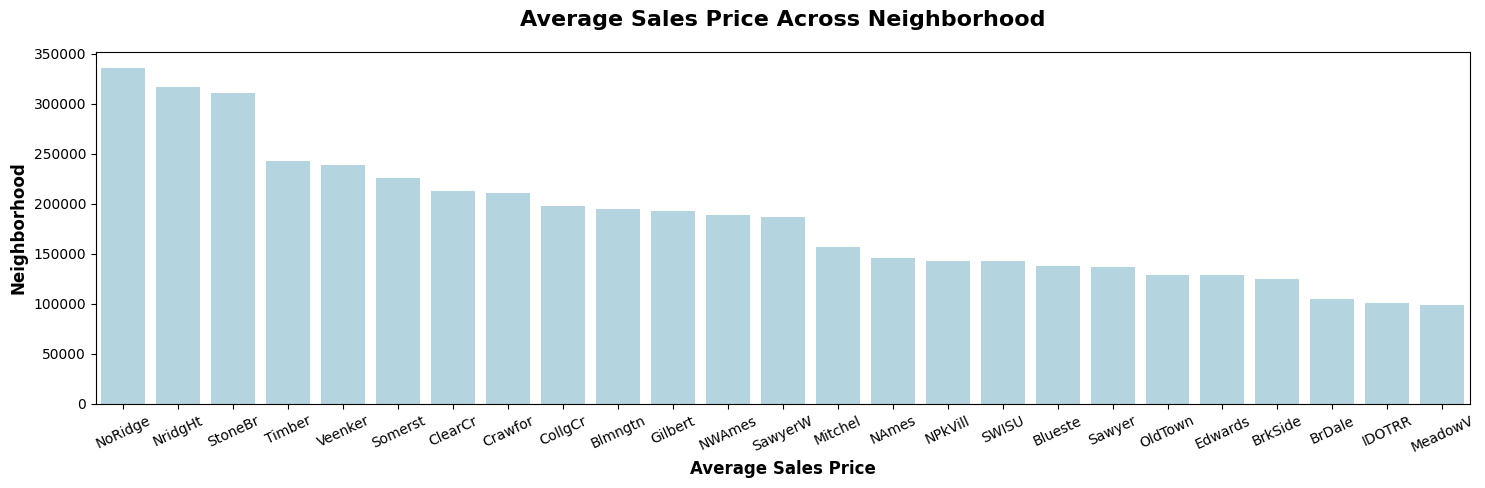

In [22]:
# Aggregate average sale price of house by neighborhood

avg_sales_df = (
    new_df.groupby(['Neighborhood'])
    .agg(
        avg_sales = ("SalePrice", 'mean')
    )
    .sort_values(by='avg_sales',ascending=False)
    .reset_index()
)
# Visualization
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(
    data=avg_sales_df, 
    x='Neighborhood', y='avg_sales',
    color='lightblue', ax=ax)
ax.set_title("Average Sales Price Across Neighborhood", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("Average Sales Price", fontsize=12, fontweight='bold')
ax.set_ylabel("Neighborhood", fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

From above chart, average house prices vary across neighborhoods. Some areas have much higher prices, often because they are more desirable or affluent neighborhoods. Northridge has the highest prices, which is three times greater than those in Meadow Village, the cheapest neighborhood.

Will use dendrogram to see if houses from the same neighborhood group together, which would show that neighborhood helps explain price differences.
To build the dendogram, we only use the SalePrice data since we're focused on comparing house prices within each neighbourhood.

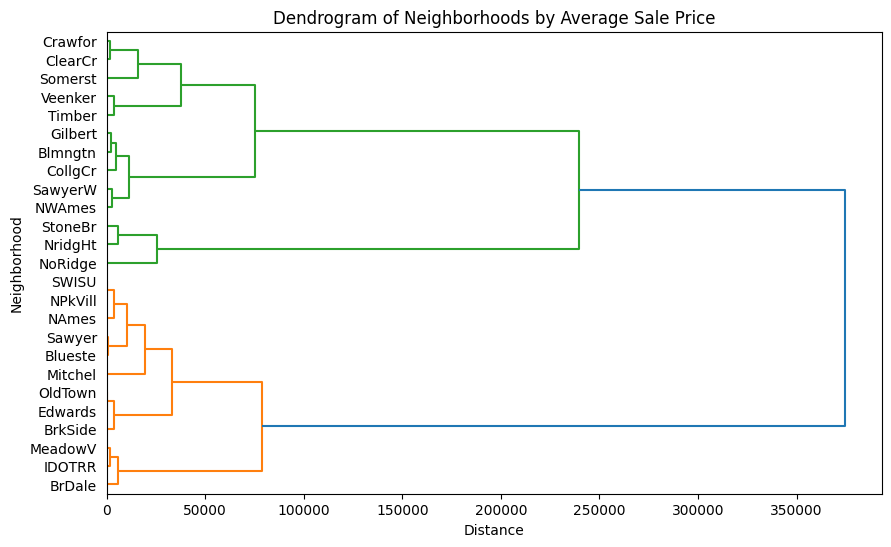

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Load your dataset
#df = pd.read_csv("train.csv")  # Ames dataset from Kaggle

# Group by neighborhood and calculate average sale price
neighborhood_prices = new_df.groupby("Neighborhood")["SalePrice"].mean()

# Convert to DataFrame for clustering
data = neighborhood_prices.values.reshape(-1, 1)

# Perform hierarchical clustering
linked = linkage(data, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, labels=neighborhood_prices.index, orientation='right')
plt.title("Dendrogram of Neighborhoods by Average Sale Price")
plt.xlabel("Distance")
plt.ylabel("Neighborhood")
plt.show()


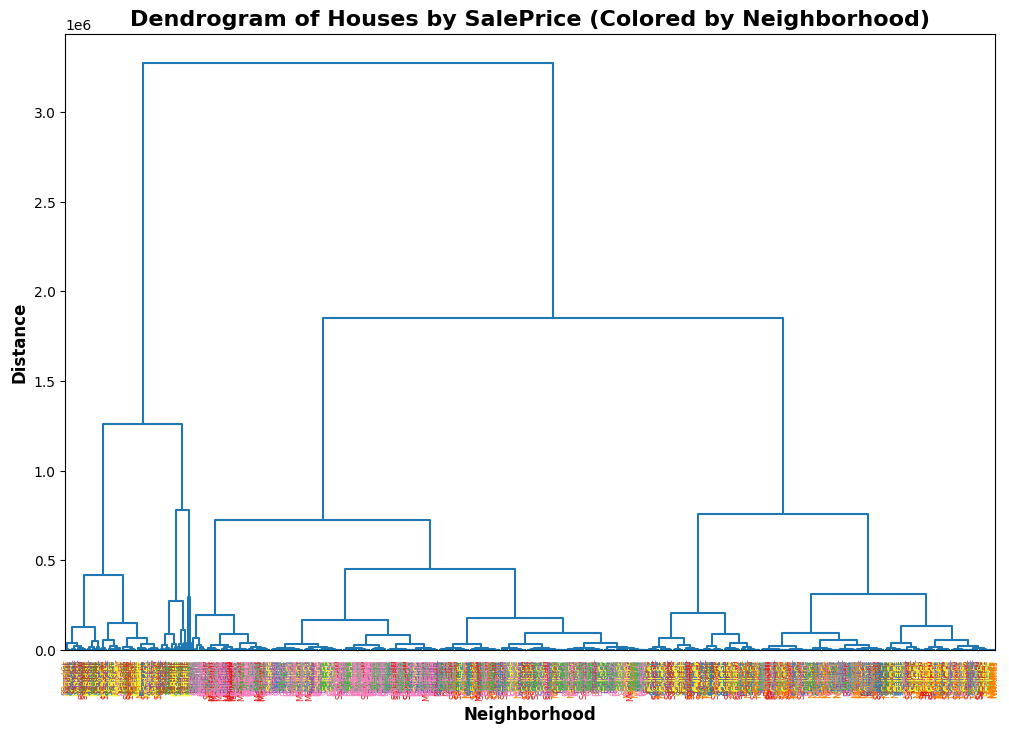

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder

# Load dataset
#df = pd.read_csv("train.csv")  # Ames dataset

# Select SalePrice and Neighborhood
prices = new_df[["SalePrice", "Neighborhood"]]

# Encode neighborhoods into numeric labels for coloring
le = LabelEncoder()
prices["NeighborhoodCode"] = le.fit_transform(prices["Neighborhood"])

# Perform hierarchical clustering on SalePrice only
linked = linkage(prices[["SalePrice"]], method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dend = dendrogram(
    linked,
    labels=prices["Neighborhood"].values,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0  # ensures branches are colored
)

# Color the leaf labels by neighborhood
ax = plt.gca()
for lbl in ax.get_xticklabels():
    neighborhood = lbl.get_text()
    code = le.transform([neighborhood])[0]
    # Assign colors based on neighborhood code
    colors = plt.cm.Set1(code % 10)  # cycle through 20 distinct colors
    lbl.set_color(colors)

plt.title("Dendrogram of Houses by SalePrice (Colored by Neighborhood)", fontsize=16, fontweight='bold')
plt.xlabel("Neighborhood", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.show()


Once the clusters are formed, we color the leaves by neighborhood. Even though there are many houses, we just check if the same colors group together. They do--- yellow on the left, pink in the middle, green on the right and blue further right. This indicate that houses within each neighborhood are similar to each other in terms of their sale prices. 

**2.2. Relationship between house size and saleprice can vary across neighborhoods.**

---
**`Question .` How do a home's age and whether it has been remodeled affect its price?**

We aim to investigate the relationship between a house's age and its sale price. Typically, older homes tend to be less attractive and may sell for lower prices due to accumulated wear and tear. However, many homeowners renovate or remodel before listing their property, aiming to enhance appeal and boost market value. 
To explore this dynamic, we beign by examining how house age correlates/relates with sale price through scatter plot.

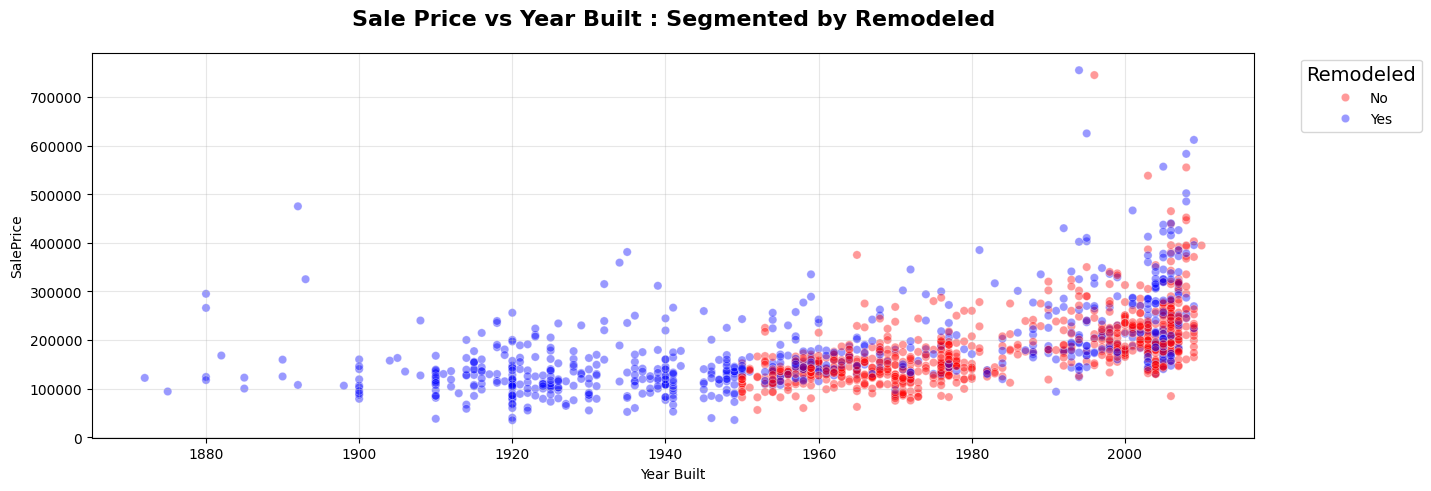

In [25]:
# Computed a new binary categorical feature Remodeled by using 2 features YearBuilt and YearRemodAdd
new_df['Remodeled'] = np.where(new_df['YearBuilt'] != new_df['YearRemodAdd'], "Yes", "No")

# Visualization 
fig, ax = plt.subplots(figsize=(15, 5))
sns.scatterplot(
    data=new_df, 
    x='YearBuilt', y='SalePrice',
    hue='Remodeled', palette={"Yes": "blue", "No":"red"},
    alpha=0.4, ax=ax
)
ax.set_title("Sale Price vs Year Built : Segmented by Remodeled", fontsize=16, fontweight='bold',y=1.05)
ax.set_xlabel("Year Built")
ax.set_ylabel("SalePrice")
ax.legend(title='Remodeled', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1), fancybox=True)

plt.grid(True, alpha=0.3)
plt.show()

The above chart, plots the Yearbuilt of house on x-axis, SalePrice on y-axis with data segmented by colors representing if house was remodeled or not. The dataset includes a quantative feature called `YearRemodAdd`, which represents the remodel year of house. If there is no remodel/renovation or addition, then `YearRemodAdd` feature is same as the built year, or `YearBuilt`. Using these two features, computed a new binary categorical feature called `Remodeled` with two values: "Yes" if `YearRemodAdd` != `YearBuilt`, and "No" otherwise.

The scatter plot shows that newer houses usually sell for more, but it’s not a strict rule --- some older homes also have decent prices, and some newer ones don't. A key finding is that every house built before 1950 has been remodeled, yet those remodeled older homes still sell for less. For houses built after 1950, whether remodeled or not, seems their prices follow a similar pattern. This suggests that for houses built more recently, remodeling doesn't have a major effect on their sale prices.


The best way to test this idea would be to compare house prices before and after remodeling. But since the dataset only includes the final sale price, we don't have information about the value of the home before renovation.

We used the final sale prices to test whether remodeling affects house values. Specifically, we ran a two-sample t-test comparing remodeled and non-remodeled houses built after 1950. First, we filtered the data to only include homes built after 1950, then split them into two groups based on remodeling status. Our null hypothesis was that the average sale prices of the two groups are equal, and the alternative was that they differ .


In [26]:
# Filter houses built after 1950
after_1950 = new_df[new_df['YearBuilt'] > 1950]

# Split into two groups based on 'remodeled status'
remodel_grp = after_1950[after_1950['Remodeled'] == 'Yes']['SalePrice']
non_remodel_grp = after_1950[after_1950['Remodeled'] == 'No']['SalePrice']

print(f"Remodel Group Average Sale Price : ${remodel_grp.mean():,.2f}")
print(f"Non-Remodel Group Average Sale Price : ${non_remodel_grp.mean():,.2f}")
# Check for normal distribution by shapiro-wilk test
print(f'\nCheck Normality assumption for Remodel for Non-Remodel Groups:')
# shapiro-wilk test for each group
_, p_shapiro1 = stats.shapiro(remodel_grp)
_, p_shapiro2 = stats.shapiro(non_remodel_grp)

print(' Shapiro-Wilk Test p-value:')
print(f" - Remodel Group = : shapiro p-value = {p_shapiro1:.4f} ({'NON-NORMAL' if p_shapiro1 < 0.05 else 'NORMAL'})")
print(f" - Non-Remodel Group = : shapiro p-value = {p_shapiro2:.4f} ({'NON-NORMAL' if p_shapiro2 < 0.05 else 'NORMAL' })")

# check equal variance assumption:
_, p_levene = stats.levene(remodel_grp, non_remodel_grp)
print("\nCheck Homogeneity of Variance assumption between 2 groups:")
print(f" - Levene's Test p-value = {p_levene:.4f}")
print(f" - Variance are {'NOT EQUAL' if p_levene < 0.05 else 'EQUAL'}")

# Decide weather to use equal variance assumption based on levene's test
if p_levene < 0.05:
    equal_var = False
    print(" - Use Weltch's t-test (for unequal variance).")
else:
    print(" - Use regular t-test (for equal variance).")


Remodel Group Average Sale Price : $219,902.26
Non-Remodel Group Average Sale Price : $183,721.83

Check Normality assumption for Remodel for Non-Remodel Groups:
 Shapiro-Wilk Test p-value:
 - Remodel Group = : shapiro p-value = 0.0000 (NON-NORMAL)
 - Non-Remodel Group = : shapiro p-value = 0.0000 (NON-NORMAL)

Check Homogeneity of Variance assumption between 2 groups:
 - Levene's Test p-value = 0.0000
 - Variance are NOT EQUAL
 - Use Weltch's t-test (for unequal variance).


In [27]:
# Perform Welch's t-test
t_stat, p_value = stats.ttest_ind(remodel_grp, non_remodel_grp, equal_var=False)

# Print the results
print(f"Welch's t-test results:\nT-statistic = {t_stat:.4f}, P-value = {p_value:.4f}")

# Decision Rule:
if p_value < 0.05:
    print(f'\nResult: Statistically significance difference in average sale price between two groups.')
else:
    print(f'\nResult: No statistically significance difference in average sale price between two groups.')



Welch's t-test results:
T-statistic = 6.6380, P-value = 0.0000

Result: Statistically significance difference in average sale price between two groups.


**Key Finding :**
- The __large positive T-statistic__ shows that remodeled houses built after 1950 have **much higher average sale prices** compared to non-remodeled ones.

- The **p-value of essentially zero** means this difference is __highly statistically significant__ — it's extremely unlikely to be due to chance.

This suggests that, the data shows a clear difference in average sale price between 2 group's houses. Although, we can't say for sure that remodeling a house directly causes the increase in price significantly, we can say at least that **remodeled houses tend to sell for higher prices than non-remodeled ones, especially for homes built after 1950.** 

---

`Question `. How does the way a house is sold affect its sale price? Specifically, how do the sale type and sale condition relate to sale price and reveal homeowner patterns?

From the above analysis, we understand the housing demographics in Ames, now look at how homes are purchased and how this relates to sale price. This means examining the features SaleType, SaleCondition, and SalePrice. Studying these factors helps us better understand the local market, property values, and broader real estate trends.

In [28]:
df_train[['SaleType','SaleCondition', 'SalePrice']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   SaleType       1460 non-null   object
 1   SaleCondition  1460 non-null   object
 2   SalePrice      1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [29]:
dtype_df.loc[['SaleType','SaleCondition', 'SalePrice'],:]

,Dtype,nunique,unique
SaleType,object,9,"[WD, New, COD, ConLD, ConLI, CWD, ConLw, Con, ..."
SaleCondition,object,6,"[Normal, Abnorml, Partial, AdjLand, Alloca, Fa..."
SalePrice,int64,663,"[208500, 181500, 223500, 140000, 250000, 14300..."


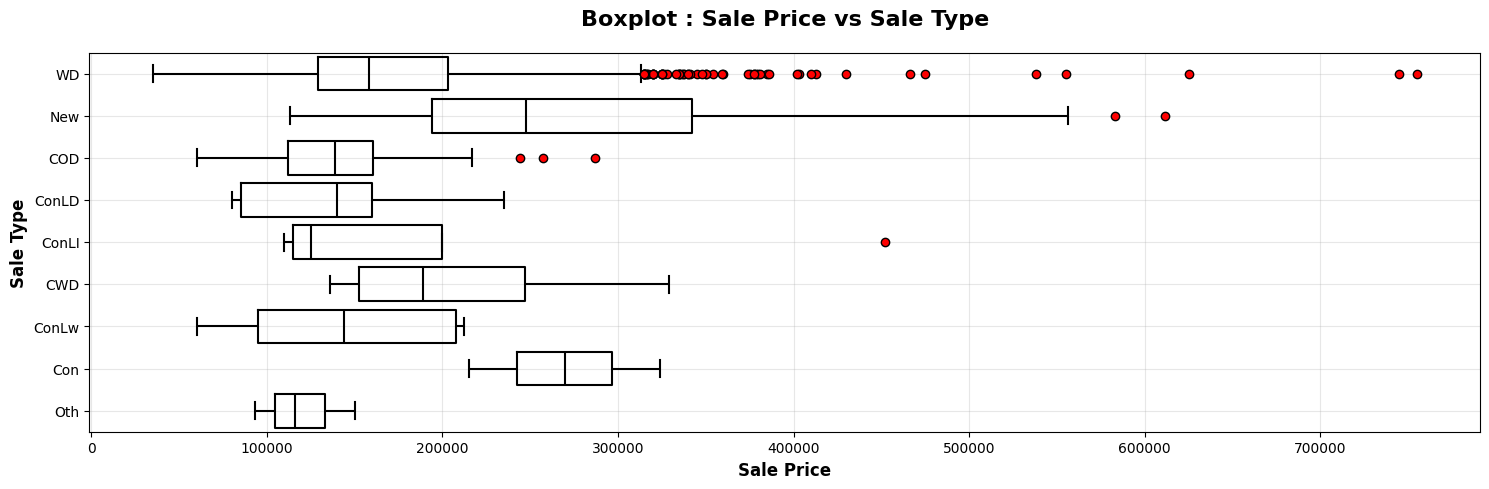

In [30]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    data=new_df,
    x='SalePrice', y='SaleType',
    fill=False, color='k',
    flierprops=dict(marker='o', markerfacecolor='r'),
    ax=ax
)

ax.set_title("Boxplot : Sale Price vs Sale Type", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("Sale Price", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Type", fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Aggregrate saleprice median by saletype
median_price = (
    new_df.groupby(['SaleType'])
    .agg(
        Median_SalePrice = ("SalePrice", "median")
    )
    .sort_values(by='Median_SalePrice', ascending=False)
    .reset_index()
    
)
median_price

,SaleType,Median_SalePrice
0,Con,269600.00
1,New,247453.00
2,CWD,188750.00
3,WD,158000.00
4,ConLw,144000.00
5,ConLD,140000.00
6,COD,139000.00
7,ConLI,125000.00
8,Oth,116050.00


In [32]:
new_df.groupby(['SaleType'])['SalePrice'].apply(lambda x: x.quantile(0.75)-x.quantile(0.25)).sort_values(ascending=False)

SaleType
New     147869.50
ConLw   112500.00
CWD      94350.00
ConLI    85000.00
ConLD    75000.00
WD       74025.00
Con      54400.00
COD      48500.00
Oth      28250.00
Name: SalePrice, dtype: float64

In [33]:
new_df.groupby(['SaleType'])['SalePrice'].describe()

,count,mean,std,min,25%,50%,75%,max
SaleType,,,,,,,,
COD,43.00,143973.26,47098.29,60000.00,112000.00,139000.00,160500.00,287000.00
CWD,4.00,210600.00,86421.49,136000.00,152500.00,188750.00,246850.00,328900.00
Con,2.00,269600.00,76933.22,215200.00,242400.00,269600.00,296800.00,324000.00
ConLD,9.00,138780.89,53876.56,79900.00,85000.00,140000.00,160000.00,235128.00
ConLI,5.00,200390.00,145282.52,110000.00,115000.00,125000.00,200000.00,451950.00
ConLw,5.00,143700.00,67291.90,60000.00,95000.00,144000.00,207500.00,212000.00
New,122.00,274945.42,103239.58,113000.00,194050.25,247453.00,341919.75,611657.00
Oth,3.00,119850.00,28441.04,93500.00,104775.00,116050.00,133025.00,150000.00
WD,1267.00,173401.84,71129.69,34900.00,128925.00,158000.00,202950.00,755000.00


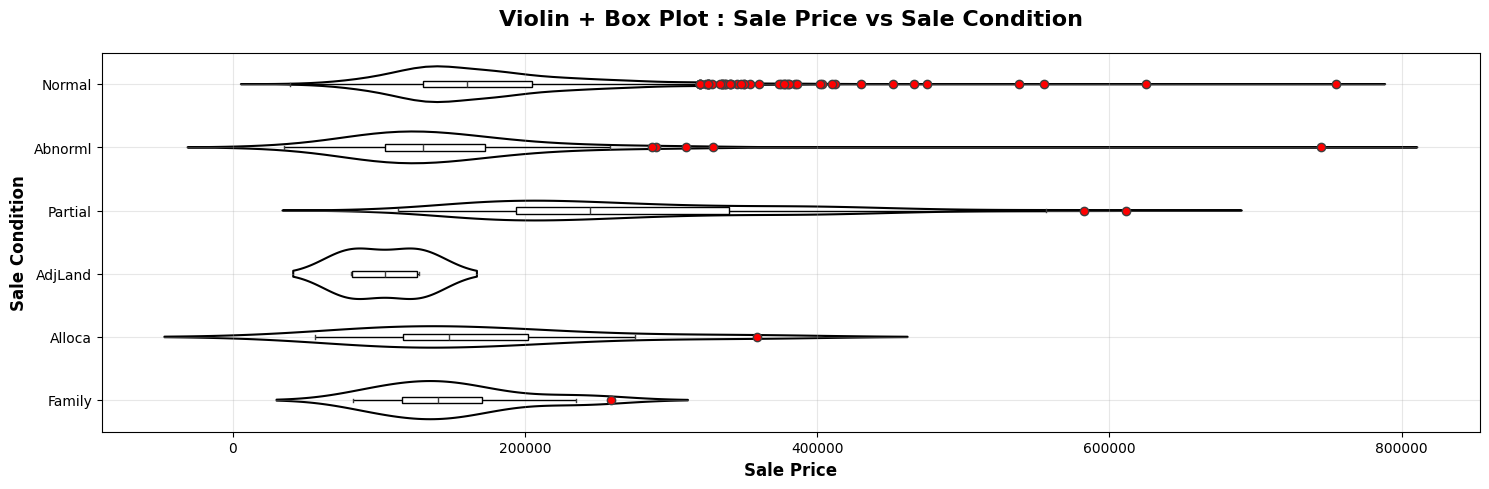

In [34]:
fig, ax = plt.subplots(figsize=(15, 5))
# Violin plot
sns.violinplot(
    data=new_df,
    x='SalePrice', y='SaleCondition',
    inner=None,
    fill=False, color='k',
    ax=ax
)

# Overlay boxplot
sns.boxplot(
    data=new_df,
    x='SalePrice', y='SaleCondition',
    width=0.1, showcaps=True,
    boxprops={'facecolor':'white', 'edgecolor':'k'},
    whiskerprops={'color':'k'},
    flierprops={'marker':'o', 'markerfacecolor':'r'},
    ax=ax
)

ax.set_title("Violin + Box Plot : Sale Price vs Sale Condition", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("Sale Price", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Condition", fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [35]:
median_saleprice = (
    new_df.groupby(['SaleCondition'])
    .agg(
        Median_SalePrice = ("SalePrice", "median")
    )
    .sort_values(by='Median_SalePrice', ascending=False)
    .reset_index()
)
median_saleprice

,SaleCondition,Median_SalePrice
0,Partial,244600.00
1,Normal,160000.00
2,Alloca,148145.00
3,Family,140500.00
4,Abnorml,130000.00
5,AdjLand,104000.00


In [36]:
new_df.query("SaleCondition=='Partial'").groupby(['Neighborhood', 'HouseStyle', 'OverallQual']).size().unstack().fillna(0)

OverallQual               4    5    6     7    8    9    10
Neighborhood HouseStyle                                    
Blmngtn      1Story     0.00 0.00 0.00  4.00 1.00 0.00 0.00
ClearCr      1Story     0.00 1.00 0.00  0.00 0.00 0.00 0.00
CollgCr      1Story     0.00 0.00 0.00 10.00 0.00 0.00 0.00
             2Story     0.00 0.00 2.00  3.00 3.00 0.00 0.00
Crawfor      1Story     0.00 0.00 0.00  0.00 1.00 0.00 0.00
Edwards      1Story     0.00 1.00 0.00  0.00 0.00 0.00 0.00
             2Story     0.00 0.00 0.00  0.00 0.00 0.00 2.00
             SFoyer     0.00 0.00 1.00  0.00 0.00 0.00 0.00
Gilbert      1Story     0.00 0.00 1.00  3.00 0.00 0.00 0.00
             2Story     0.00 0.00 3.00  5.00 0.00 0.00 0.00
Mitchel      1Story     0.00 1.00 0.00  0.00 0.00 0.00 0.00
NridgHt      1Story     0.00 0.00 0.00  5.00 7.00 6.00 3.00
             2Story     0.00 0.00 0.00  1.00 3.00 6.00 1.00
OldTown      1Story     0.00 1.00 0.00  0.00 0.00 0.00 0.00
             2Story     1.00 0.00 0.00  0.00 0.00 0.00 0.00
SawyerW      1Story     0.00 0.00 1.00  0.00 0.00 0.00 0.00
Somerst      1Story     0.00 0.00 2.00  9.00 9.00 2.00 0.00
             2Story     0.00 0.00 2.00  5.00 4.00 0.00 0.00
StoneBr      1Story     0.00 0.00 0.00  0.00 3.00 2.00 0.00
             2Story     0.00 0.00 0.00  0.00 1.00 1.00 1.00
Timber       1Story     0.00 0.00 0.00  0.00 5.00 0.00 0.00
             2Story     0.00 0.00 0.00  1.00 1.00 0.00 0.00

`Question :` How do a house's quality and condition affect house price, and how does the average sale price change over time with the economy?

We want to see how a house's features—like its overall condition and quality—vary across homes in Ames and how they influence sale prices. We'll also look at how average sale prices have changed over time, highlighting major shifts during events such as the Great Depression(1929-39) and the Global Financial Crisis(2008). For this, will use the features like YearBuilt, SalePrice, OverallQuality, and OverallCondition to create visualizations.

We'll start by looking at how many houses in Ames fall into different quality and condition ratings. This helps us understand the overall housing market and the types of homes that exist there. To show this, we'll use a heat map comparing Overall Quality and Overall Condition of houses.

In [37]:
dtype_df.loc[['OverallCond', 'OverallQual'],:]

,Dtype,nunique,unique
OverallCond,int64,9,"[5, 8, 6, 7, 4, 2, 3, 9, 1]"
OverallQual,int64,10,"[7, 6, 8, 5, 9, 4, 10, 3, 1, 2]"


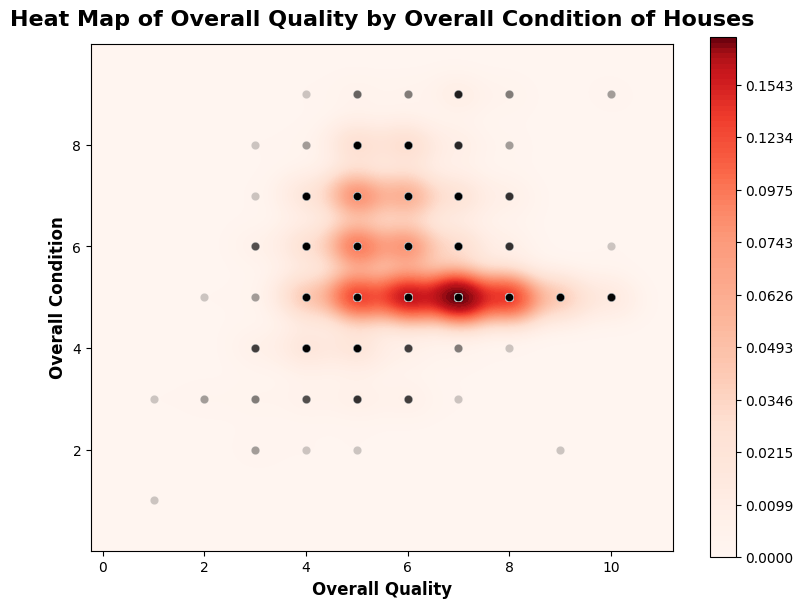

In [38]:

fig, ax = plt.subplots(figsize=(8,6))

# 2D density heatmap
kde = sns.kdeplot(
    data=new_df,
    x="OverallQual",
    y="OverallCond",
    fill=True,
    cmap="Reds",
    thresh=0,
    levels=100,
    cbar=True,
    ax=ax
)

#Scatter points
sns.scatterplot(
    data=new_df,
    x="OverallQual",
    y="OverallCond",
    alpha=0.2,
    color="k",
    ax=ax
)

ax.set_title("Heat Map of Overall Quality by Overall Condition of Houses", fontsize=16, fontweight='bold', y=1.02)
ax.set_xlabel("Overall Quality", fontsize=12, fontweight='bold')
ax.set_ylabel("Overall Condition", fontsize=12, fontweight='bold')
ax.set_aspect('equal', adjustable='box')  # coord_fixed equivalent


plt.tight_layout()
plt.show()



In [39]:
new_df['OverallCond'].value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

In [40]:
new_df['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

The above heat map shows, some houses with certain combinations of quality and condition appear brighter red, showing higher density. The most common group in Ames has an overall quality around 7 and condition around 5. The next most common are houses with condition 5 and qualities of 5, 6, or 8. This means that many homes share an average condition, while their quality ranges from average to very good.

To explore this further, we'll look at how the house's yearbuilt relates to its sale price, segmented the data by overall quality. This will show how the quality of homes in Ames has changed over time, whether certain quality levels dominated during specific periods, and how quality affects sale prices. Below is a time series plot of YearBuilt vs. SalePrice, grouped by OverallQuality.

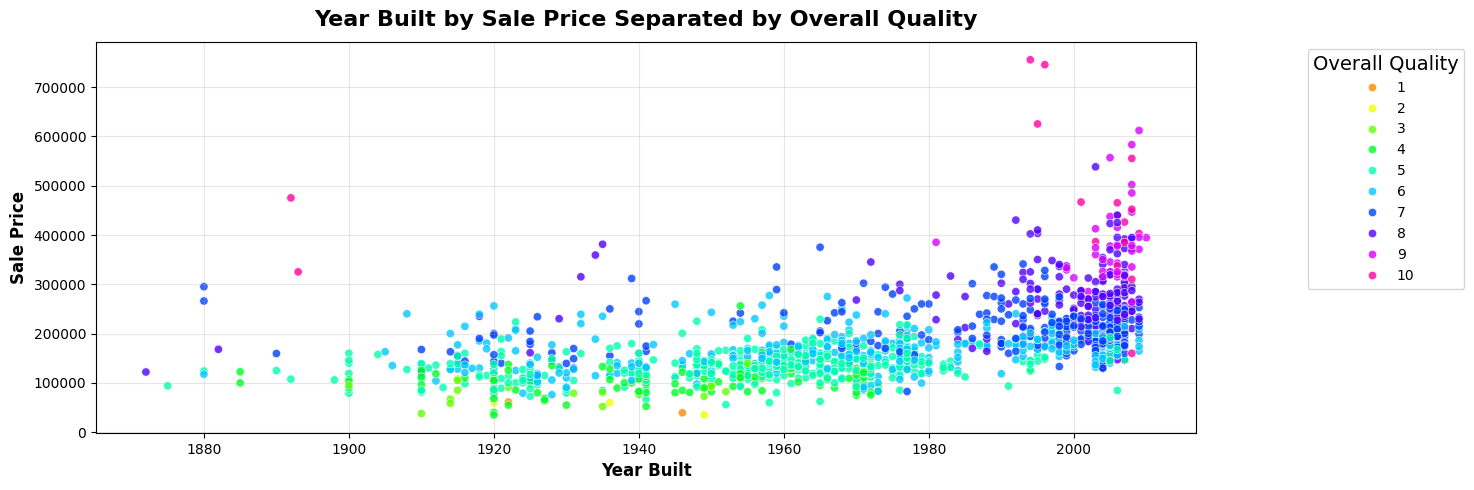

In [41]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.scatterplot(
    data=new_df,
    x="YearBuilt",
    y="SalePrice",
    hue="OverallQual",   # color by overall quality
    hue_order=range(1, 11),
    alpha=0.8,
    palette=sns.color_palette("hsv", 10)  
)
ax.set_title("Year Built by Sale Price Separated by Overall Quality", fontsize=16, fontweight='bold', y=1.02)
ax.set_xlabel("Year Built", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Price", fontsize=12, fontweight='bold')
ax.legend(title="Overall Quality", title_fontsize=14, bbox_to_anchor=(1.25, 1), fancybox=True, loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The time series shows that house prices stayed fairly steady until about 1980, then began rising and peaked around 2000, following a slight exponential growth. The overall quality of homes also shifted during this time. Earlier houses, especially those built in the early 1900s, mostly had average to good quality ratings (5, 6, or 7). From the 1980s onward, we start seeing homes rated very good to excellent (8, 9, and 10).

This suggests that for a long period, most houses built in Ames were of average quality, which may reflect the rural setting and cost-of-living expectations. That consistency in quality likely kept sale prices stable until the 1980s. After that, prices tripled by the early 2000s, pointing to significant changes during that period. To better understand this trend, we’ll create another plot showing the moving average of sale prices over time.

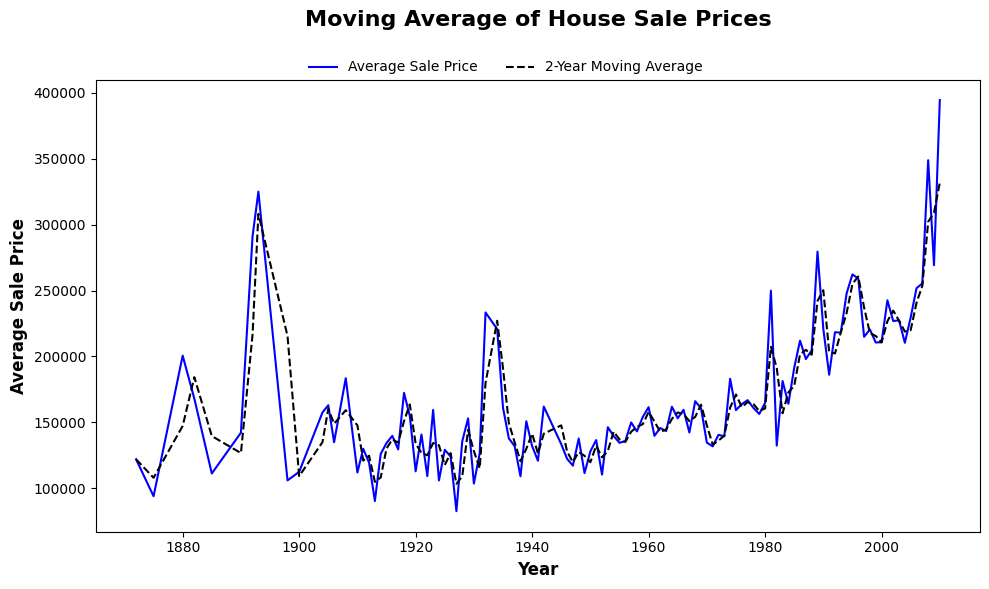

In [42]:
# Calculate average sale price per year
average_sale_price = (
    new_df
    .groupby("YearBuilt")["SalePrice"]
    .mean()
    .reset_index(name="Avg_Sale_Price")
)

# Compute moving average (window = 2, align left)
average_sale_price["Moving_Avg"] = (
    average_sale_price["Avg_Sale_Price"]
    .rolling(window=2, min_periods=1)
    .mean()
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(average_sale_price["YearBuilt"], average_sale_price["Avg_Sale_Price"], 
         color="blue", label="Average Sale Price")
plt.plot(average_sale_price["YearBuilt"], average_sale_price["Moving_Avg"], 
         color="k", linestyle="--", label="2-Year Moving Average")

plt.title("Moving Average of House Sale Prices", y=1.10, fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Average Sale Price", fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(0.7, 1.07), loc='upper right', ncols=2, frameon=False)
plt.tight_layout()
plt.show()


The moving average shows that house prices have generally risen over time, with sharp ups and downs during certain years. Around 1890, prices dropped, likely due to the Panic of 1893, which caused unemployment and bank failures and reduced housing demand. Another decline happened around 1930–1940 during the Great Depression, when demand for homes fell again. After these periods, prices began rising steadily, driven by stronger economic activity and higher living costs.

In summary, these graphs show that rising housing prices aren’t just an urban issue—they’ve also affected rural areas. For a long time, Ames had mostly average-quality homes, but in recent years both quality and condition have improved. This shift, driven by higher living costs and economic growth, has led to much higher sale prices.

### **Conclusion**

In this analysis, we saw how the housing market in Ames, Iowa has changed over time and how different features of houses can be studied to understand those changes.

First, we looked at the overall housing market in Ames to see what kind of houses and features are most common. We did this by examining house styles, how they vary across neighborhoods, and how amenities have changed over time. Using an MDS plot on house size(square feet) colored by house style, we found that one-story, one-and-a-half-story, and two-story homes are the most common. A stacked bar chart showed that neighborhoods like North Ames and College Creek have more houses, while affluent neighborhood like Gilbert tend to have larger homes. Finally, we used a time series and regression analysis to study amenities such as garage area, basement area and porch size. We found that basement and garage space are positively related to sale price, with basement size having the strongest effect. All amenities were significant, though there are some limitations that future analysis should address.

**Remodeling and non-remodeling** : Remodeled house tend to sell for higher prices than non-remodeled ones, especially for homes built after 1950. We can't be sure how remodeling affects sale prices as we had access to data for post-renovation sale prices.

Finally, we looked at how the overall quality and condition of houses affect sale prices and how prices have changed over time. Using time series plots with year built, sale price, and quality and condition, we found that homes with higher ratings(quality and condition) generally sell on higher price. Most houses in Ames, have average quality and condition. Only in recent decades have we seen more homes with higher ratings, likely due to economic growth and rising living costs. This supports our earlier point that housing prices have increased disproportionately, even in rural areas, because of demand and cost of living.